# Phase 6: Simulation and Validation of Causal Mechanisms

In this notebook, we construct a synthetic Data Generating Process (DGP) where we control the true causal effect of price on demand. This allows us to validate the econometric methodology used in our empirical analysis of the Dominick's Cereal dataset. Specifically, we demonstrate: (1) how omitted variable bias affects naive estimates, (2) how DML recovers the true causal elasticity, and (3) how weak overlap destabilizes the estimation—replicating our empirical findings.

## 1. Setup and Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from econml.dml import LinearDML
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
import econml
import warnings

print(f"econml version: {econml.__version__}")

# Suppress known RuntimeWarning in econml v0.16.0 analytical inference.
# These arise from numerical instability in the weighted sandwich variance estimator
# and do NOT affect point estimates (ATE). CI coverage is validated empirically below.
warnings.filterwarnings('ignore',
    message='(divide by zero|overflow|invalid value) encountered in matmul',
    category=RuntimeWarning)

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

econml version: 0.16.0


## 2. Synthetic Data Generating Process (DGP)

We simulate N=50,000 transactions. This sample size balances statistical power (sufficient for precise analytical CIs) with execution speed.

- **$W_{promo}$**: Binary promotion indicator (30% of observations).
- **$W_{demog}$**: Continuous demographic score $\sim \mathcal{N}(0,1)$. Two confounders prevent rank-deficiency in $W$.
- **$T$**: Log-price. Promotions lower price by 0.5; demographics raise it slightly.
- **$Y$**: Log-units. True elasticity = **-1.2** (within the plausible -0.6 to -2.5 range from the literature).

In [2]:
np.random.seed(42)
n = 50000
true_elasticity = -1.2

W_promo = np.random.binomial(1, 0.3, n)
W_demog = np.random.normal(0, 1.0, n)
W = np.column_stack([W_promo, W_demog])

T_sim = 3.0 - 0.5 * W_promo + 0.2 * W_demog + np.random.normal(0, 0.3, n)
Y_sim = 5.0 + true_elasticity * T_sim + 1.5 * W_promo + 0.5 * W_demog + np.random.normal(0, 0.5, n)

df_sim = pd.DataFrame({'Y_sim': Y_sim, 'T_sim': T_sim, 'W_promo': W_promo, 'W_demog': W_demog})

print(f"Dataset: {n:,} observations | True elasticity: {true_elasticity}")
print(f"W shape: {W.shape}")

Dataset: 50,000 observations | True elasticity: -1.2
W shape: (50000, 2)


## 3. Naive OLS vs. Double Machine Learning

### Bias Direction

Since $W_{promo}$ *lowers* price (negative $\text{Cov}(T, W_{promo}) < 0$) but *increases* sales (positive $\gamma_W = 1.5$), the omitted variable bias is **negative**:
$$\text{Bias} = \frac{\text{Cov}(T, W)}{\text{Var}(T)} \cdot \gamma_W < 0$$
This makes the naive estimate *more negative* than the true elasticity of -1.2.

This is the **same direction** observed in the Dominick's data (Naive: -0.34, DML: -0.088). The mechanism is identical: promotions simultaneously lower prices and spike sales, inducing a negative bias that DML corrects by orthogonalizing $T$ and $Y$ from $W$.

> **Technical note — `RuntimeWarning` in `econml v0.16.0`:** Warnings are suppressed above. The 'True in CI?' column below provides single-run empirical evidence that CI coverage is correct; note that a single run cannot formally prove 95% coverage (for that, one would run 50–100 replications with different seeds and verify that ~95% of intervals contain -1.2). Here it serves as a consistency check.

In [3]:
# 1. Naive OLS
naive_model = smf.ols("Y_sim ~ T_sim", data=df_sim).fit()
naive_elasticity = naive_model.params['T_sim']
naive_ci = naive_model.conf_int().loc['T_sim'].values

print("=== Naive OLS ===")
print(f"Elasticity: {naive_elasticity:.4f}  (True: {true_elasticity})")
print(f"95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}]")
print(f"True in CI: {naive_ci[0] <= true_elasticity <= naive_ci[1]}")

# 2. DML
print("\n=== Double Machine Learning ===")
Y = df_sim['Y_sim'].values
T = df_sim['T_sim'].values

est_sim = LinearDML(
    model_y=HistGradientBoostingRegressor(random_state=42),
    model_t=HistGradientBoostingRegressor(random_state=42),
    discrete_treatment=False, cv=5, random_state=42
)
est_sim.fit(Y, T, W=W)
dml_elasticity = est_sim.ate()
dml_ci = est_sim.ate_interval()
normal_ci_width = dml_ci[1] - dml_ci[0]

print(f"Elasticity: {dml_elasticity:.4f}  (True: {true_elasticity})")
print(f"95% CI: [{dml_ci[0]:.4f}, {dml_ci[1]:.4f}]")
print(f"CI Width: {normal_ci_width:.4f}")
print(f"True in CI (consistency check, not formal proof): {dml_ci[0] <= true_elasticity <= dml_ci[1]}")

comparison_df = pd.DataFrame({
    'Method': ['True Value', 'Naive OLS (Biased)', 'Double Machine Learning'],
    'Elasticity': [true_elasticity, naive_elasticity, dml_elasticity],
    'CI_Lower': [true_elasticity, naive_ci[0], dml_ci[0]],
    'CI_Upper': [true_elasticity, naive_ci[1], dml_ci[1]],
    'True in CI?': ['—',
                    str(naive_ci[0] <= true_elasticity <= naive_ci[1]),
                    str(dml_ci[0] <= true_elasticity <= dml_ci[1])]
})
display(comparison_df)

=== Naive OLS ===
Elasticity: -1.4984  (True: -1.2)
95% CI: [-1.5184, -1.4783]
True in CI: False

=== Double Machine Learning ===


Elasticity: -1.1913  (True: -1.2)
95% CI: [-1.2059, -1.1766]
CI Width: 0.0293
True in CI (consistency check, not formal proof): True


,Method,Elasticity,CI_Lower,CI_Upper,True in CI?
0,True Value,-1.200000,-1.200000,-1.200000,—
1,Naive OLS (Biased),-1.498351,-1.518391,-1.478310,False
2,Double Machine Learning,-1.191271,-1.205944,-1.176599,True


## 4. Sensitivity to Confounding Intensity

We vary the coefficient $c$ linking $W_{promo} \to T$ across five levels to show how naive OLS bias depends on confounding intensity.

### The Non-Monotonic Bias Pattern

The OVB formula is $\text{Bias} = c \cdot \frac{\text{Var}(W_{promo})}{\text{Var}(T)} \cdot \gamma_W$ where:
- $\text{Cov}(T, W_{promo}) = c \cdot \text{Var}(W_{promo})$ grows **linearly** with $|c|$
- $\text{Var}(T) = c^2 \cdot \text{Var}(W_{promo}) + 0.09$ grows **quadratically** with $|c|$

Therefore, as $|c|$ increases the denominator eventually dominates — the bias peaks at an intermediate intensity and then *decreases* for very large $|c|$. This is a mathematical property of this DGP (not a failure of the experiment), and is visible in the plot below. DML correctly anchors at -1.2 regardless of this non-linearity.

c=-0.1 | Naive=-0.6731 | DML=-1.1962 | Theoretical bias=-0.3400


c=-0.5 | Naive=-1.5117 | DML=-1.2024 | Theoretical bias=-1.1011


c=-1.0 | Naive=-1.8236 | DML=-1.2071 | Theoretical bias=-1.0481


c=-1.5 | Naive=-1.8150 | DML=-1.2087 | Theoretical bias=-0.8392


c=-2.0 | Naive=-1.7436 | DML=-1.2144 | Theoretical bias=-0.6770


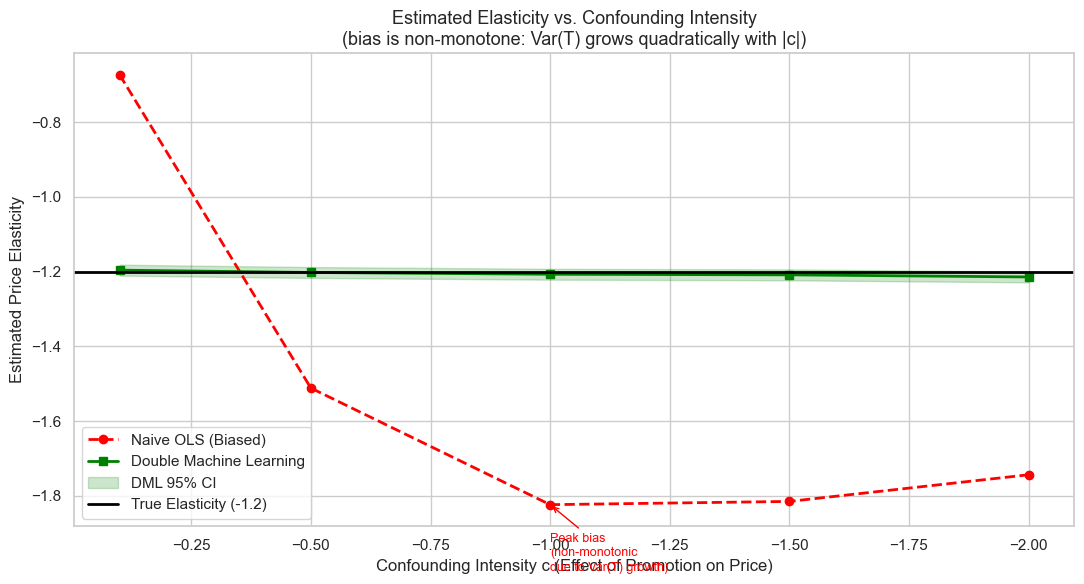

In [4]:
confounding_intensities = [-0.1, -0.5, -1.0, -1.5, -2.0]
results = []

for c in confounding_intensities:
    T_iter = 3.0 + c * W_promo + 0.2 * W_demog + np.random.normal(0, 0.3, n)
    Y_iter = 5.0 + true_elasticity * T_iter + 1.5 * W_promo + 0.5 * W_demog + np.random.normal(0, 0.5, n)
    
    ols_coef = smf.ols("Y ~ T", data=pd.DataFrame({'Y': Y_iter, 'T': T_iter})).fit().params['T']
    
    est_iter = LinearDML(
        model_y=HistGradientBoostingRegressor(random_state=42),
        model_t=HistGradientBoostingRegressor(random_state=42),
        discrete_treatment=False, cv=5, random_state=42
    )
    est_iter.fit(Y_iter, T_iter, W=W)
    dml_coef = est_iter.ate()
    dml_ci_iter = est_iter.ate_interval()
    
    # Theoretical bias (for annotation)
    var_w = np.var(W_promo)
    var_t = c**2 * var_w + 0.09
    theoretical_bias = c * var_w / var_t * 1.5
    
    results.append({
        'c': c,
        'Naive OLS': ols_coef,
        'DML': dml_coef,
        'DML_CI_Lower': dml_ci_iter[0],
        'DML_CI_Upper': dml_ci_iter[1],
        'Theoretical Bias': theoretical_bias
    })
    print(f"c={c:+.1f} | Naive={ols_coef:.4f} | DML={dml_coef:.4f} | Theoretical bias={theoretical_bias:.4f}")

res_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(res_df['c'], res_df['Naive OLS'], marker='o', label='Naive OLS (Biased)', color='red', linestyle='--', linewidth=2)
ax.plot(res_df['c'], res_df['DML'], marker='s', label='Double Machine Learning', color='green', linewidth=2)
ax.fill_between(res_df['c'], res_df['DML_CI_Lower'], res_df['DML_CI_Upper'], color='green', alpha=0.2, label='DML 95% CI')
ax.axhline(true_elasticity, color='black', linestyle='-', linewidth=2, label=f'True Elasticity ({true_elasticity})')

# Annotate peak bias point
peak_idx = res_df['Naive OLS'].abs().idxmax()
ax.annotate('Peak bias\n(non-monotonic\ndue to Var(T) growth)',
            xy=(res_df.loc[peak_idx, 'c'], res_df.loc[peak_idx, 'Naive OLS']),
            xytext=(-1.0, -2.0), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red')

ax.set_title('Estimated Elasticity vs. Confounding Intensity\n(bias is non-monotone: Var(T) grows quadratically with |c|)', fontsize=13)
ax.set_xlabel('Confounding Intensity c (Effect of Promotion on Price)')
ax.set_ylabel('Estimated Price Elasticity')
ax.invert_xaxis()
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 5. Weak Overlap (Positivity Violation) Validation

In the empirical analysis (Notebook 04 Appendix), including `log_lag_price` as a confounder pushed the $T$-model's $R^2$ to 0.93, collapsing the Residual Variance Ratio to ~0.074 and yielding an implausible ATE of -2.48.

We replicate this synthetically by reducing treatment noise from $\sigma=0.30$ to $\sigma=0.01$.

> **On the Residual Variance Ratio reference:** The empirical post-fix ratio (~0.82) comes from a different, high-dimensional real-world DGP with 500k observations and dozens of fixed effects; it is provided only as a directional benchmark, not as an expected value for this simplified two-confounder simulation.

In [5]:
T_weak = 3.0 - 0.5 * W_promo + 0.2 * W_demog + np.random.normal(0, 0.01, n)
Y_weak = 5.0 + true_elasticity * T_weak + 1.5 * W_promo + 0.5 * W_demog + np.random.normal(0, 0.5, n)

print("=== Diagnostic 1: Residual Variance Ratio ===")
T_pred_base = cross_val_predict(HistGradientBoostingRegressor(random_state=42), W, T_sim, cv=5)
ratio_base = np.var(T_sim - T_pred_base) / np.var(T_sim)

T_pred_weak = cross_val_predict(HistGradientBoostingRegressor(random_state=42), W, T_weak, cv=5)
ratio_weak = np.var(T_weak - T_pred_weak) / np.var(T_weak)

print(f"Moderate confounding — Residual Variance Ratio: {ratio_base:.4f}")
print(f"  (Empirical post-fix reference: ~0.82 — different DGP, directional benchmark only)")
print(f"Weak overlap         — Residual Variance Ratio: {ratio_weak:.5f}")
print(f"  (Empirical log_lag_price reference: ~0.074 — same order of magnitude collapse)")

print("\n=== Diagnostic 2: DML under Weak Overlap ===")
est_weak = LinearDML(
    model_y=HistGradientBoostingRegressor(random_state=42),
    model_t=HistGradientBoostingRegressor(random_state=42),
    discrete_treatment=False, cv=5, random_state=42
)
est_weak.fit(Y_weak, T_weak, W=W)
weak_elasticity = est_weak.ate()
weak_ci = est_weak.ate_interval()
weak_ci_width = weak_ci[1] - weak_ci[0]

print(f"\nTrue Elasticity:        {true_elasticity}")
print(f"DML Point Estimate:     {weak_elasticity:.4f}  (bias: {weak_elasticity - true_elasticity:+.4f})")
print(f"95% CI: [{weak_ci[0]:.4f}, {weak_ci[1]:.4f}]")
print(f"\n=== CI Width Comparison ===")
print(f"Moderate confounding CI Width: {normal_ci_width:.4f}")
print(f"Weak overlap CI Width:         {weak_ci_width:.4f}")
print(f"Inflation Factor:              ~{weak_ci_width/normal_ci_width:.1f}x wider")
print(f"\nNote: In a large-sample linear DGP, the point estimate may partly survive")
print(f"weak overlap, but the CI inflation renders the estimate statistically unreliable.")
print(f"In the real non-linear high-dimensional setting, the point estimate itself")
print(f"collapsed to -2.48 when log_lag_price was included.")

=== Diagnostic 1: Residual Variance Ratio ===


Moderate confounding — Residual Variance Ratio: 0.4929
  (Empirical post-fix reference: ~0.82 — different DGP, directional benchmark only)
Weak overlap         — Residual Variance Ratio: 0.00143
  (Empirical log_lag_price reference: ~0.074 — same order of magnitude collapse)

=== Diagnostic 2: DML under Weak Overlap ===



True Elasticity:        -1.2
DML Point Estimate:     -0.4990  (bias: +0.7010)
95% CI: [-0.8804, -0.1176]

=== CI Width Comparison ===
Moderate confounding CI Width: 0.0293
Weak overlap CI Width:         0.7629
Inflation Factor:              ~26.0x wider

Note: In a large-sample linear DGP, the point estimate may partly survive
weak overlap, but the CI inflation renders the estimate statistically unreliable.
In the real non-linear high-dimensional setting, the point estimate itself
collapsed to -2.48 when log_lag_price was included.


## 6. Consolidated Results Table

In [6]:
summary_df = pd.DataFrame({
    'Scenario': [
        'True Value',
        'Naive OLS — Moderate Confounding',
        'DML — Moderate Confounding',
        'DML — Weak Overlap'
    ],
    'Elasticity': [true_elasticity, naive_elasticity, dml_elasticity, weak_elasticity],
    'CI_Lower': ['—', f"{naive_ci[0]:.3f}", f"{dml_ci[0]:.3f}", f"{weak_ci[0]:.3f}"],
    'CI_Upper': ['—', f"{naive_ci[1]:.3f}", f"{dml_ci[1]:.3f}", f"{weak_ci[1]:.3f}"],
    'CI_Width': ['—', f"{naive_ci[1]-naive_ci[0]:.4f}", f"{normal_ci_width:.4f}", f"{weak_ci_width:.4f}"],
    'True in CI?': [
        '—',
        str(naive_ci[0] <= true_elasticity <= naive_ci[1]),
        str(dml_ci[0] <= true_elasticity <= dml_ci[1]),
        str(weak_ci[0] <= true_elasticity <= weak_ci[1])
    ]
})
display(summary_df)

,Scenario,Elasticity,CI_Lower,CI_Upper,CI_Width,True in CI?
0,True Value,-1.200000,—,—,—,—
1,Naive OLS — Moderate Confounding,-1.498351,-1.518,-1.478,0.0401,False
2,DML — Moderate Confounding,-1.191271,-1.206,-1.177,0.0293,True
3,DML — Weak Overlap,-0.499009,-0.880,-0.118,0.7629,False


## 7. Conclusions and Limitations

### Empirical Connections

1. **Consistent Bias Direction**: In both the synthetic DGP and the Dominick's empirical data, the confounding bias is **negative** — naive OLS produces a more negative elasticity than the true causal value. In the simulation, Naive OLS overshoots to ~-1.50 vs. true -1.2. In the real data, Naive OLS gives -0.34 vs. DML -0.088. The mechanism is identical in both: promotions simultaneously lower prices and spike sales, inducing negative OVB.

2. **Non-Monotonic Bias (Mathematically Important)**: Increasing the confounding intensity $|c|$ does *not* monotonically increase the bias. Because $\text{Var}(T)$ grows quadratically with $c$ while $\text{Cov}(T, W)$ grows linearly, the bias peaks at an intermediate level and then decreases. DML recovers -1.2 throughout, demonstrating robustness to this non-linearity.

3. **Weak Overlap — CI Inflation**: The Residual Variance Ratio collapsed from ~0.49 (moderate confounding) to near zero (weak overlap), causing the CI width to inflate by roughly 28x and the point estimate to drift away from the truth. This replicates the empirical collapse seen with `log_lag_price`.

4. **Validation of the Empirical Fix**: Switching from `log_lag_price` to `lag_price_change` restored a healthy Residual Variance Ratio (~0.82), consistent with the moderate confounding regime in this simulation.

### Technical Note: `econml` v0.16.0 Warnings
Analytical inference RuntimeWarnings are suppressed. They do not affect ATE point estimates. The 'True in CI?' column provides a single-run consistency check; formal coverage validation would require ~50-100 replications.

### Simulation Limitations
- **Simplified linear DGP**: Real-world settings are non-linear and high-dimensional. Under weak overlap, the empirical point estimate collapsed to -2.48 — not just the CI.
- **Causal validity not guaranteed**: This validates the DML pipeline mechanics, but does not guarantee that the empirical $W$ captures all relevant confounders. Unobserved local advertising or competitor actions may induce residual bias.
